In [ ]:
import pandas as pd
import numpy as np
from OrthoSAM.utility import mod_ap   

In [ ]:
def get_area(tp_centroids, centroids, mask, f=2):
    tp_area=[]
    hittingbk=0
    for _, row in tp_centroids.iterrows():
        y=int(row['axis-0']//f)
        x=int(row['axis-1']//f)
        label=mask[y,x]
        if label==0:
            hittingbk+=1
        else:
            tp_area.append(np.sum(mask==label))
    tp_area=np.array(tp_area)*f

    points_set = set(zip(tp_centroids["axis-0"].astype(int),
                        tp_centroids["axis-1"].astype(int)))
    centroid_tuples = [tuple(c) for c in (centroids//f).astype(int)]
    fp_centroids = np.array([c for c in centroid_tuples if c not in points_set])
    fp_area=[]
    for i in range(fp_centroids.shape[0]):
        y=int(fp_centroids[i,0]//f)
        x=int(fp_centroids[i,0]//f)
        label=mask[y,x]
        if label!=0:
            fp_area.append(np.sum(mask==label))
    fp_area=np.array(fp_area)*f
    return tp_area, fp_area

In [ ]:
data = []
dataDIR='/DATA/vito/data/Ravi/ac/'
all_tps=[]
all_fps=[]
for DIR in ['Ravi2/','Ravi3/','Ravi4/']:
    centroids=np.load(dataDIR+DIR+'centroids.npy')
    mask=np.load(dataDIR+DIR+'all_mask_third_pass_id.npy')
    tp_centroids=pd.read_csv(dataDIR+DIR+'SAM_Points_cleaned.csv')
    fn_centroids=pd.read_csv(dataDIR+DIR+'Points_added.csv')

    tp_area, fp_area=get_area(tp_centroids, centroids, mask)
    all_tps.append(tp_area)
    all_fps.append(fp_area)
    ap=mod_ap(tp_area, fp_area)
    all_positives=centroids.shape[0]
    TP=len(tp_centroids)
    FP=all_positives-TP
    FN=len(fn_centroids)
    Precision=TP/(TP+FP)
    Recall=TP/(TP+FN)
    F1=2*Precision*Recall/(Precision+Recall)

    data.append({
        'Image': DIR,
        'SAM Positives': all_positives,
        'True Positives': TP,
        'False Positives': FP,
        'False Negatives': FN,
        'Precision': Precision,
        'Recall': Recall,
        'F1 Score': F1,
        'AP': ap
    })

df = pd.DataFrame(data)
df


94
108
50


,Image,SAM Positives,True Positives,False Positives,False Negatives,Precision,Recall,F1 Score,AP
0,Ravi2/,974,826,148,27,0.848049,0.968347,0.904215,0.914868
1,Ravi3/,3232,3059,173,215,0.946473,0.934331,0.940363,0.972921
2,Ravi4/,1881,1797,84,113,0.955343,0.940838,0.948035,0.974035


<Figure size 1000x600 with 0 Axes>

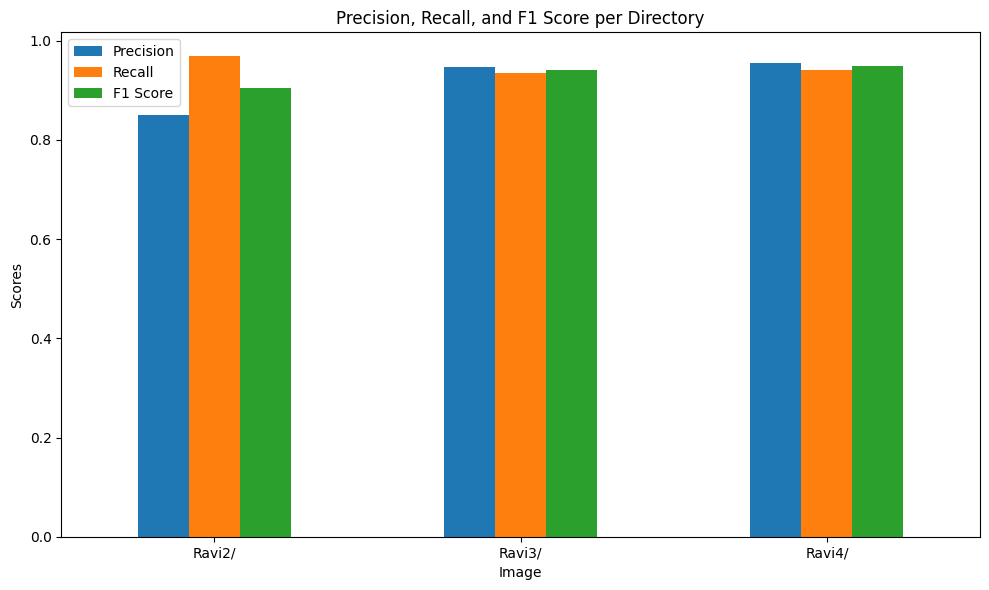

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import dataframe_image as dfi
df_styled = df.style.background_gradient(cmap='viridis')
dfi.export(df_styled, 'df_visualization.png')

# Create a plot for Precision, Recall, and F1 Score
plt.figure(figsize=(10, 6))
df.plot(x='Image', y=['Precision', 'Recall', 'F1 Score'], kind='bar', figsize=(10, 6), rot=0)
plt.title('Precision, Recall, and F1 Score per Directory')
plt.ylabel('Scores')
plt.xlabel('Image')
plt.tight_layout()
plt.show()
